
=== Résumé du dataset ===
Nombre total de lignes : 29910
Colonnes utilisées :
  - type d'énergie : primary_fuel
  - capacité       : capacity_mw
  - pays/région    : country

=== Valeurs manquantes ===
primary_fuel: 0
capacity_mw: 0
country: 0

=== Distribution des types d'énergie ===
primary_fuel
Hydro             7155
Solar             5929
Wind              5188
Gas               3922
Coal              2390
Oil               2290
Biomass           1396
Waste             1087
Nuclear            198
Geothermal         189
Storage             58
Other               44
Cogeneration        41
Petcoke             13
Wave and Tidal      10

Type d'énergie dominant : Hydro (7155 centrales, 23.92%)

=== Statistiques de capacité (MW) ===
count    29910.000000
mean       186.294810
std        525.703572
min          1.000000
25%          4.774430
50%         18.900000
75%        100.000000
max      22500.000000

=== Top 10 pays/régions par nombre de centrales ===
country
USA    8686
CHN    30

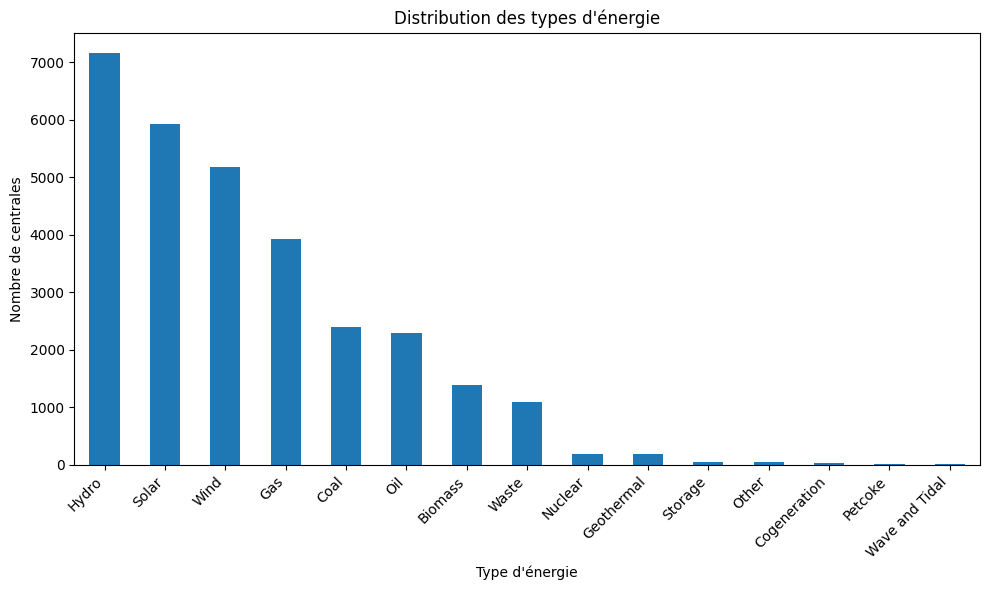

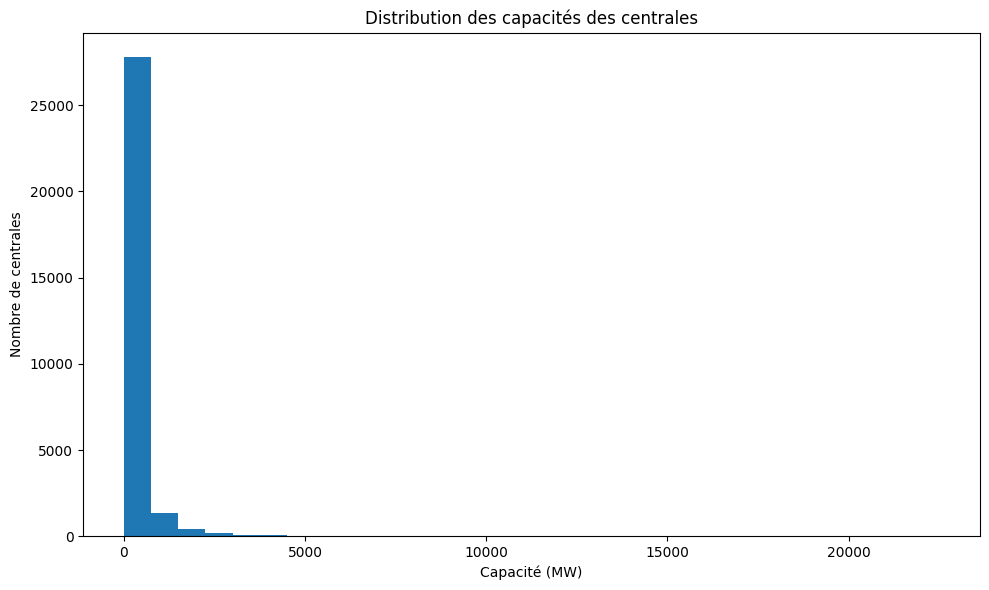

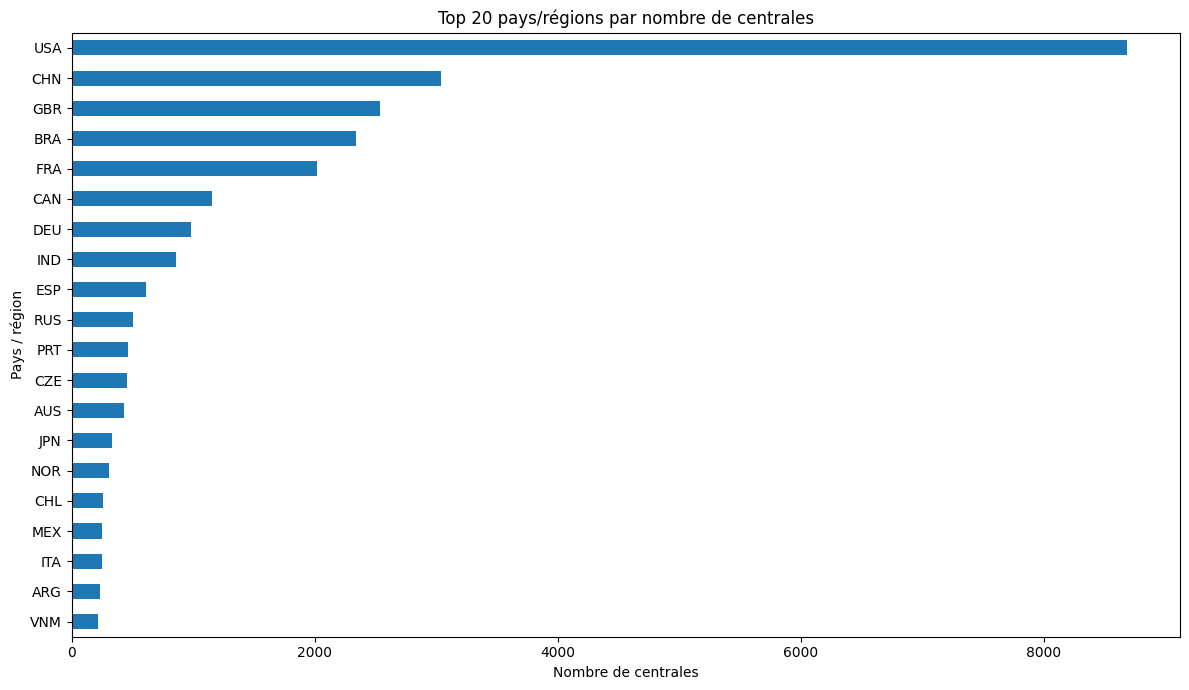

In [ ]:
#!/usr/bin/env python3
"""
EDA simple pour un dataset de power plants.

Fonctionnalités :
- distribution des types d'énergie
- histogramme des capacités (MW)
- nombre de centrales par pays/région
- petit résumé texte dans le terminal

Usage :
    python eda_power_plants.py data.csv

Ou avec colonnes explicites :
    python eda_power_plants.py data.csv --fuel-col primary_fuel --capacity-col capacity_mw --country-col country_long

Sauvegarder les figures :
    python eda_power_plants.py data.csv --output-dir results
"""

from __future__ import annotations

import argparse
import os
import sys
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import pandas as pd


def normalize_column_name(name: str) -> str:
    return name.strip().lower().replace(" ", "_")


def find_column(df: pd.DataFrame, candidates: list[str]) -> Optional[str]:
    normalized = {normalize_column_name(col): col for col in df.columns}
    for candidate in candidates:
        if candidate in normalized:
            return normalized[candidate]
    return None


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Exploration univariée d'un dataset de power plants."
    )
    parser.add_argument(
        "csv_file",
        type=str,
        help="Chemin vers le fichier CSV."
    )
    parser.add_argument(
        "--fuel-col",
        type=str,
        default=None,
        help="Nom de la colonne du type d'énergie."
    )
    parser.add_argument(
        "--capacity-col",
        type=str,
        default=None,
        help="Nom de la colonne de capacité en MW."
    )
    parser.add_argument(
        "--country-col",
        type=str,
        default=None,
        help="Nom de la colonne pays/région."
    )
    parser.add_argument(
        "--top-n-countries",
        type=int,
        default=20,
        help="Nombre de pays/régions à afficher dans le bar chart."
    )
    parser.add_argument(
        "--bins",
        type=int,
        default=30,
        help="Nombre de bins pour l'histogramme des capacités."
    )
    parser.add_argument(
        "--output-dir",
        type=str,
        default=None,
        help="Dossier où sauvegarder les graphiques. Si absent, affiche seulement les figures."
    )
    return parser.parse_args()


def validate_file(path: str) -> Path:
    file_path = Path(path)
    if not file_path.exists():
        print(f"Erreur : fichier introuvable : {file_path}", file=sys.stderr)
        sys.exit(1)
    if not file_path.is_file():
        print(f"Erreur : ce chemin n'est pas un fichier : {file_path}", file=sys.stderr)
        sys.exit(1)
    return file_path


def infer_columns(df: pd.DataFrame, args: argparse.Namespace) -> tuple[str, str, str]:
    fuel_col = args.fuel_col or find_column(
        df,
        [
            "primary_fuel",
            "fuel_type",
            "fuel",
            "energy_type",
            "source",
            "generation_type",
        ],
    )

    capacity_col = args.capacity_col or find_column(
        df,
        [
            "capacity_mw",
            "capacity",
            "installed_capacity_mw",
            "net_capacity_mw",
            "mw",
        ],
    )

    country_col = args.country_col or find_column(
        df,
        [
            "country",
            "country_long",
            "country_name",
            "region",
            "area",
        ],
    )

    missing = []
    if fuel_col is None:
        missing.append("type d'énergie")
    if capacity_col is None:
        missing.append("capacité")
    if country_col is None:
        missing.append("pays/région")

    if missing:
        print("Impossible de détecter automatiquement :", ", ".join(missing), file=sys.stderr)
        print("Colonnes disponibles :", list(df.columns), file=sys.stderr)
        print(
            "Utilise --fuel-col, --capacity-col et/ou --country-col pour les préciser.",
            file=sys.stderr,
        )
        sys.exit(1)

    return fuel_col, capacity_col, country_col


def clean_dataframe(
    df: pd.DataFrame,
    fuel_col: str,
    capacity_col: str,
    country_col: str
) -> pd.DataFrame:
    cleaned = df.copy()

    cleaned[fuel_col] = cleaned[fuel_col].astype(str).str.strip()
    cleaned[country_col] = cleaned[country_col].astype(str).str.strip()

    cleaned.loc[cleaned[fuel_col].isin(["", "nan", "None"]), fuel_col] = pd.NA
    cleaned.loc[cleaned[country_col].isin(["", "nan", "None"]), country_col] = pd.NA

    cleaned[capacity_col] = pd.to_numeric(cleaned[capacity_col], errors="coerce")
    cleaned.loc[cleaned[capacity_col] < 0, capacity_col] = pd.NA

    return cleaned


def print_summary(
    df: pd.DataFrame,
    fuel_col: str,
    capacity_col: str,
    country_col: str
) -> None:
    print("\n=== Summary of the dataset ===")
    print(f"Total number of rows : {len(df)}")
    print(f"Columns used :")
    print(f"  - type of energy : {fuel_col}")
    print(f"  - capacity       : {capacity_col}")
    print(f"  - country/region    : {country_col}")

    print("\n=== Missing values ===")
    print(f"{fuel_col}: {df[fuel_col].isna().sum()}")
    print(f"{capacity_col}: {df[capacity_col].isna().sum()}")
    print(f"{country_col}: {df[country_col].isna().sum()}")

    print("\n=== Distribution of the types of energy ===")
    fuel_counts = df[fuel_col].dropna().value_counts()
    print(fuel_counts.to_string())

    if not fuel_counts.empty:
        dominant = fuel_counts.idxmax()
        dominant_count = fuel_counts.iloc[0]
        dominant_pct = 100 * dominant_count / fuel_counts.sum()
        print(
            f"\nDominant type of energy : {dominant} "
            f"({dominant_count} power plants, {dominant_pct:.2f}%)"
        )

    capacities = df[capacity_col].dropna()
    if not capacities.empty:
        print("\n=== Statistics of Capacities (MW) ===")
        print(capacities.describe().to_string())

    country_counts = df[country_col].dropna().value_counts().head(10)
    print("\n=== Top 10 countries/regions by number of power plants ===")
    print(country_counts.to_string())


def plot_fuel_distribution(
    df: pd.DataFrame,
    fuel_col: str,
    output_dir: Optional[Path]
) -> None:
    counts = df[fuel_col].dropna().value_counts()

    plt.figure(figsize=(10, 6))
    counts.plot(kind="bar")
    plt.title("Distribution of the types of energy")
    plt.xlabel("Type of energy")
    plt.ylabel("Number of power plants")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    if output_dir:
        plt.savefig(output_dir / "fuel_distribution.png", dpi=300, bbox_inches="tight")
    else:
        plt.show()
    plt.close()


def plot_capacity_histogram(
    df: pd.DataFrame,
    capacity_col: str,
    bins: int,
    output_dir: Optional[Path]
) -> None:
    capacities = df[capacity_col].dropna()

    plt.figure(figsize=(10, 6))
    plt.hist(capacities, bins=bins)
    plt.title("Distribution of the capacities of power plants")
    plt.xlabel("Capacity(MW)")
    plt.ylabel("Number of power plants")
    plt.tight_layout()

    if output_dir:
        plt.savefig(output_dir / "capacity_histogram.png", dpi=300, bbox_inches="tight")
    else:
        plt.show()
    plt.close()


def plot_country_counts(
    df: pd.DataFrame,
    country_col: str,
    top_n: int,
    output_dir: Optional[Path]
) -> None:
    counts = df[country_col].dropna().value_counts().head(top_n)

    plt.figure(figsize=(12, 7))
    counts.sort_values().plot(kind="barh")
    plt.title(f"Top {top_n} pays/régions par nombre de centrales")
    plt.xlabel("Nombre de centrales")
    plt.ylabel("Pays / région")
    plt.tight_layout()

    if output_dir:
        plt.savefig(output_dir / "country_counts.png", dpi=300, bbox_inches="tight")
    else:
        plt.show()
    plt.close()


df = pd.read_csv("4-power-plants.csv")

args = argparse.Namespace(
    fuel_col=None,
    capacity_col=None,
    country_col=None
)

fuel_col, capacity_col, country_col = infer_columns(df, args)

df = clean_dataframe(df, fuel_col, capacity_col, country_col)

print_summary(df, fuel_col, capacity_col, country_col)

plot_fuel_distribution(df, fuel_col, None)
plot_capacity_histogram(df, capacity_col, 30, None)
plot_country_counts(df, country_col, 20, None)

In [6]:
def plot_fuel_distribution_by_country(
    df: pd.DataFrame,
    fuel_col: str,
    country_col: str,
    top_n_countries: int,
    output_dir: Optional[Path]
) -> None:
    top_countries = df[country_col].dropna().value_counts().head(top_n_countries).index
    filtered = df[df[country_col].isin(top_countries)].dropna(subset=[fuel_col, country_col])

    crosstab = pd.crosstab(filtered[country_col], filtered[fuel_col])
    proportions = crosstab.div(crosstab.sum(axis=1), axis=0)

    plt.figure(figsize=(14, 8))
    proportions.plot(kind="bar", stacked=True, ax=plt.gca())
    plt.title("Distribution des types de power plants par pays")
    plt.xlabel("Pays")
    plt.ylabel("Proportion")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Type d'énergie", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    if output_dir:
        plt.savefig(output_dir / "fuel_distribution_by_country.png", dpi=300, bbox_inches="tight")
    else:
        plt.show()
    plt.close()

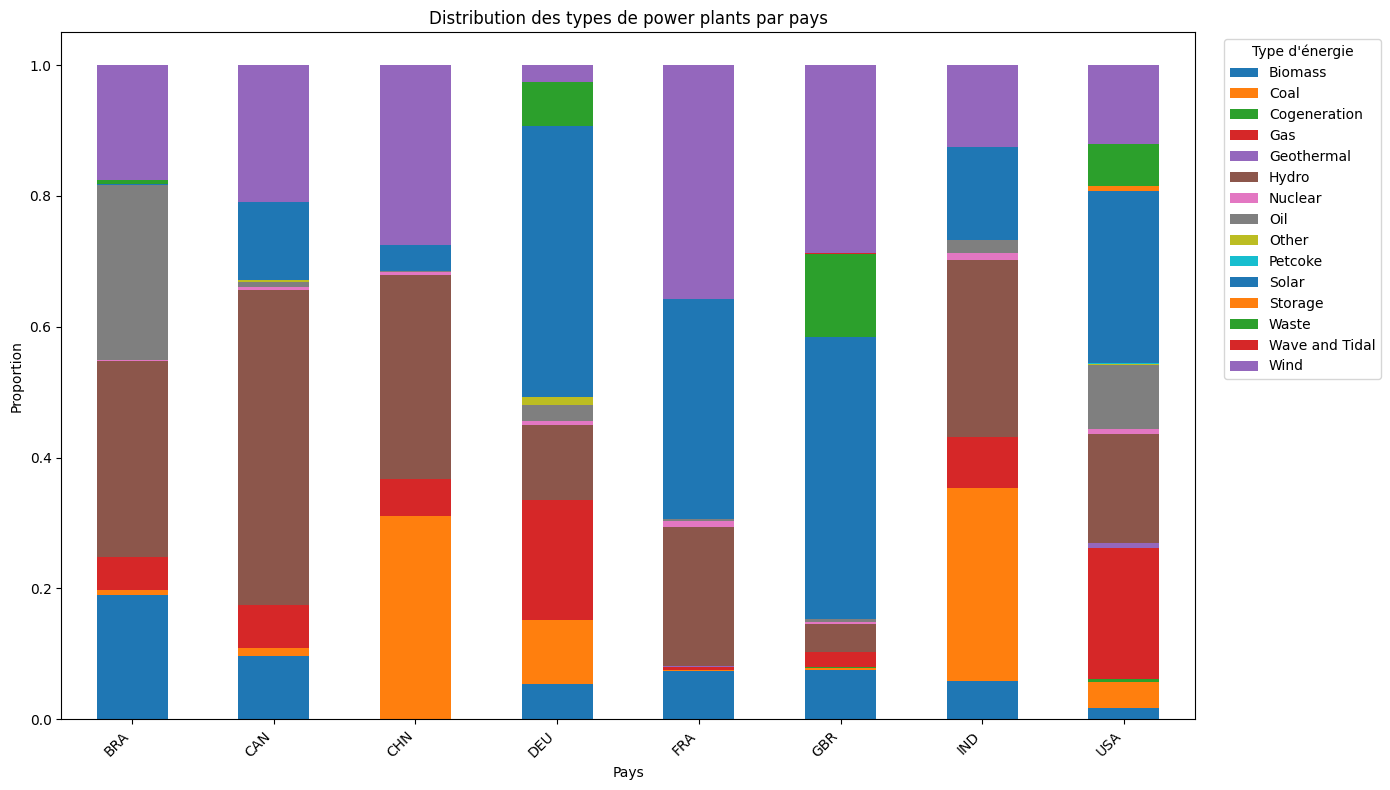

In [9]:
plot_fuel_distribution_by_country(df, fuel_col, country_col, 8, None)